# Critical-event verification

Identifies event windows where the selected synthetic-noise segment may overlap an arrival and supports manual inspection.


In [1]:
import os
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path(r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion")
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import preprocessing_utils as pp
import consensus_utils as cu

_kw = cu.synth_noise.__kwdefaults__
PRE_A, PRE_B = _kw["pre_a"], _kw["pre_b"]
print(f"Tramo de ruido: muestras {PRE_A}:{PRE_B} = {PRE_A/100:.0f}s a {PRE_B/100:.0f}s")
print(f"P teórica en la ventana: 30 s (muestra 3000)")

Tramo de ruido: muestras 200:2700 = 2s a 27s
P teórica en la ventana: 30 s (muestra 3000)


In [2]:
# Find windows whose accepted P is near the default source-segment end.
LABELING_DIR = REPO_ROOT / "data" / "processed" / "labeling"
files = sorted(glob.glob(str(LABELING_DIR / "labels_*.csv")))
labels = pd.concat([pd.read_csv(f, on_bad_lines="skip") for f in files], ignore_index=True)

eq = labels[labels["category"] == "earthquake"].copy()
eq = eq[eq["p_time_s"].notna()].copy()
print(f"Sismos con P etiquetada: {len(eq)}")

crit = eq[eq["p_time_s"] < PRE_B / 100.0].copy()
print(f"Críticos (P real < {PRE_B/100:.0f} s): {len(crit)}")
print()
print(crit[["station_code", "timestamp", "p_time_s", "s_time_s", "p_prob", "snr_p_db"]].head(12).to_string(index=False))
print()
print("Distribución de la P real en los críticos:")
print(crit["p_time_s"].describe().to_string())

Sismos con P etiquetada: 49910
Críticos (P real < 27 s): 1144

station_code         timestamp  p_time_s  s_time_s  p_prob  snr_p_db
        BRJC 2019.094.07.29.25     17.83     35.09  0.8132     14.77
        BRJC 2019.198.01.18.30     26.90     37.19  0.9261     18.52
        BRJC 2020.239.06.34.46     22.92       NaN  0.7476      9.62
        BRJC 2020.248.16.33.30     24.03     41.08  0.8482     25.54
        BRJC 2020.299.14.51.01     26.51     35.29  0.9136      6.73
        BRJC 2020.356.13.35.01     26.96     36.58  0.8933      9.33
        BRJC 2020.366.22.27.32     12.96     30.27  0.8996      6.28
        BRJC 2021.082.21.21.35     26.93     44.24  0.8225      1.99
        BRJC 2021.206.21.24.50     23.48     50.11  0.7776     16.12
        BRJC 2022.168.01.44.56     25.30       NaN  0.4823      4.02
        BRJC 2022.200.06.24.08     23.00     42.92  0.7708     19.29
        BRJC 2022.223.10.29.13     12.88     30.50  0.9163      8.60

Distribución de la P real en los crític

In [3]:
# Inspection settings
N_EJEMPLOS = 4           # cuántos eventos críticos inspeccionar
RNG_SEED = 42
n_out = pp.NPTS

sel = crit.sort_values("p_time_s").head(N_EJEMPLOS).reset_index(drop=True)
print("Eventos seleccionados (los de P más temprana):")
print(sel[["station_code", "timestamp", "p_time_s", "s_time_s"]].to_string(index=False))

Eventos seleccionados (los de P más temprana):
station_code         timestamp  p_time_s  s_time_s
         ZAR 2019.039.05.55.42      4.86     10.76
         PTB 2018.251.03.24.18      4.88     22.58
         CHI 2020.004.11.14.19      4.88     34.38
         PRA 2025.159.17.24.50      4.90     25.06


In [4]:
def analizar_evento(row, i):
    """Carga la ventana, genera la sintética y mide la contaminación."""
    sta = row["station_code"]
    ts = str(row["timestamp"])
    station_dir = REPO_ROOT / "data" / "raw" / "waveforms" / sta
    arr = pp.load_window_array(station_dir, ts, sta, preprocess=True)
    if arr is None:
        return None
    rng = np.random.default_rng(RNG_SEED + i)
    syn = cu.synth_noise(arr, n_out, rng=rng)

    p_s = int(round(row["p_time_s"] * 100))
    tramo = arr[:, PRE_A:PRE_B]
    # Compare source-segment RMS with RMS near the accepted P.
    e_tramo = np.sqrt((tramo ** 2).mean())
    # Use a short window around the accepted P for the RMS check.
    lo = max(0, p_s - 100)
    hi = min(n_out, p_s + 100)
    e_p = np.sqrt((arr[:, lo:hi] ** 2).mean())
    e_p_syn = np.sqrt((syn[:, lo:hi] ** 2).mean())
    return {
        "sta": sta, "ts": ts, "p_s": row["p_time_s"], "s_s": row["s_time_s"],
        "arr": arr, "syn": syn, "e_tramo": e_tramo, "e_p": e_p, "e_p_syn": e_p_syn,
    }

In [5]:
resultados = []
for i, row in sel.iterrows():
    r = analizar_evento(row, i)
    if r is not None:
        resultados.append(r)

print(f"Analizados: {len(resultados)} eventos")
for r in resultados:
    contaminacion = r["e_p"] / r["e_tramo"]
    sint = r["e_p_syn"] / r["e_tramo"]
    print(f"  {r['sta']} {r['ts']}  P={r['p_s']:.2f}s  | energía tramo={r['e_tramo']:.2f} "
          f"| energía en P (orig)={r['e_p']:.2f} ({contaminacion:.1f}x tramo) "
          f"| energía en P (sint)={r['e_p_syn']:.2f} ({sint:.1f}x tramo)")

Analizados: 4 eventos
  ZAR 2019.039.05.55.42  P=4.86s  | energía tramo=161.07 | energía en P (orig)=161.95 (1.0x tramo) | energía en P (sint)=138.62 (0.9x tramo)
  PTB 2018.251.03.24.18  P=4.88s  | energía tramo=548.36 | energía en P (orig)=143.48 (0.3x tramo) | energía en P (sint)=474.72 (0.9x tramo)
  CHI 2020.004.11.14.19  P=4.88s  | energía tramo=94.24 | energía en P (orig)=48.38 (0.5x tramo) | energía en P (sint)=79.72 (0.8x tramo)
  PRA 2025.159.17.24.50  P=4.90s  | energía tramo=137.16 | energía en P (orig)=105.04 (0.8x tramo) | energía en P (sint)=121.70 (0.9x tramo)


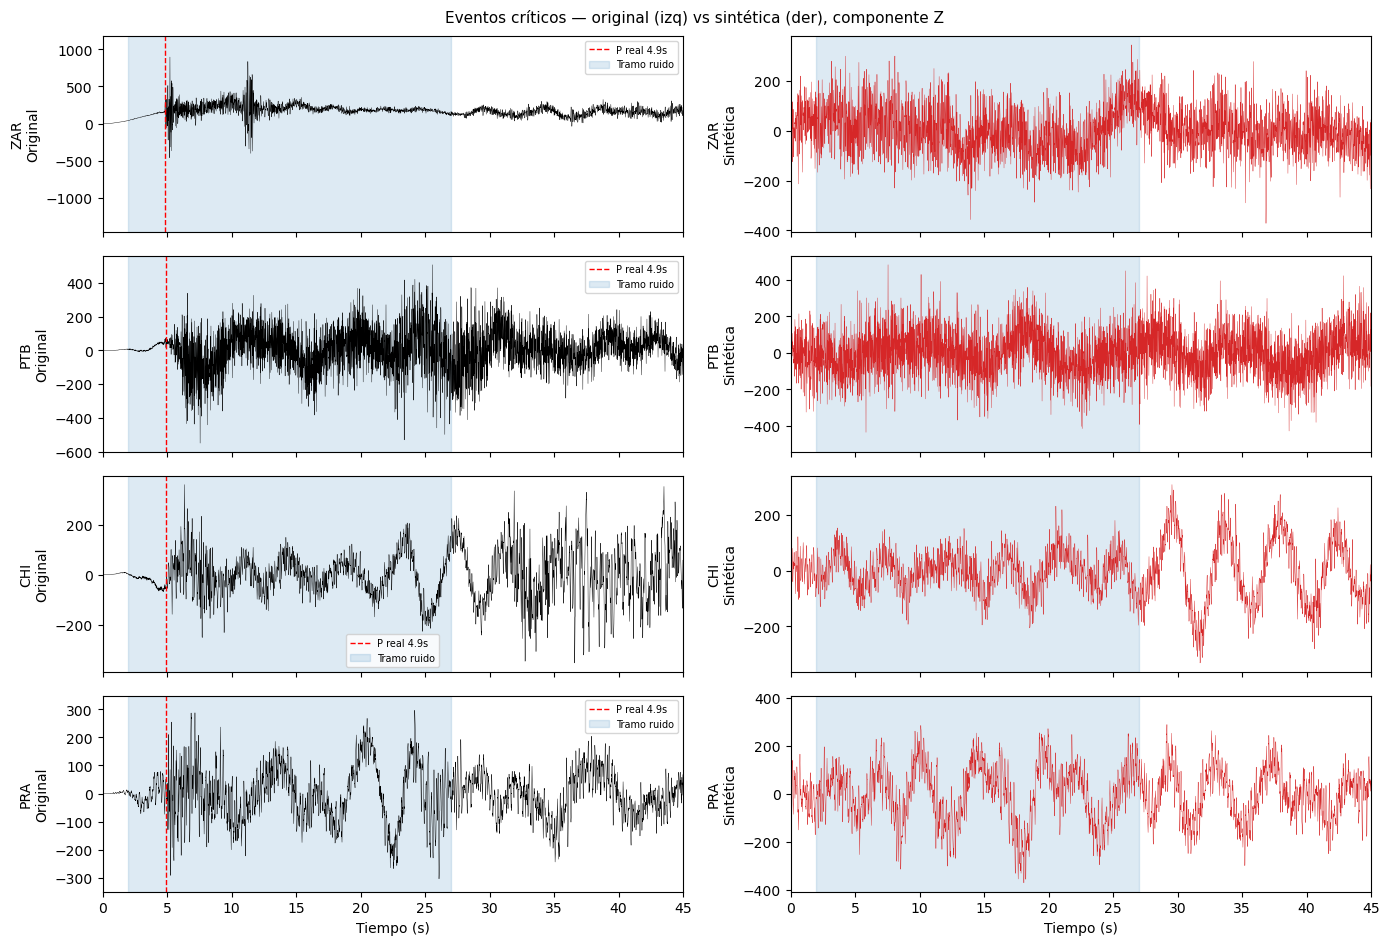

In [6]:
# Plot original and surrogate traces for selected windows.
n = len(resultados)
fig, axes = plt.subplots(n, 2, figsize=(14, 2.4 * n), sharex=True)
if n == 1:
    axes = axes.reshape(1, 2)
t = np.arange(n_out) / 100.0

for i, r in enumerate(resultados):
    axes[i][0].plot(t, r["arr"][0], lw=0.3, color="k")
    axes[i][0].axvline(r["p_s"], color="r", lw=1, ls="--", label=f"P real {r['p_s']:.1f}s")
    axes[i][0].axvspan(PRE_A / 100, PRE_B / 100, color="tab:blue", alpha=0.15, label="Tramo ruido")
    axes[i][0].set_ylabel(f"{r['sta']}\nOriginal")
    axes[i][0].set_xlim(0, 45)
    axes[i][0].legend(fontsize=7)

    axes[i][1].plot(t, r["syn"][0], lw=0.3, color="tab:red")
    axes[i][1].axvspan(PRE_A / 100, PRE_B / 100, color="tab:blue", alpha=0.15)
    axes[i][1].set_ylabel(f"{r['sta']}\nSintética")
    axes[i][1].set_xlim(0, 45)

axes[-1][0].set_xlabel("Tiempo (s)")
axes[-1][1].set_xlabel("Tiempo (s)")
fig.suptitle("Eventos críticos — original (izq) vs sintética (der), componente Z", fontsize=11)
plt.tight_layout()
plt.show()

## Interpretation

Compare RMS in the source segment and around the accepted P time for the original and surrogate traces. Large ratios identify examples for visual inspection; they do not by themselves establish whether an arrival entered the source segment.